# 第二部分 2.4：模型评估

| 章节 | 内容 |
|------|------|
| **2.8 模型评估** | 交叉验证、偏差-方差权衡、分类/回归指标 |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, make_regression, make_blobs, make_moons
from sklearn.model_selection import train_test_split

matplotlib.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
print('环境就绪')

环境就绪


## 2.8 模型评估

选择正确的评估指标和方法，是 ML 工作中经常被忽视但非常关键的一步。

### 分类指标

混淆矩阵出发：TP（真正例）、FP（假正例）、TN（真负例）、FN（假负例）

| 指标 | 公式 | 关注什么 |
|------|------|----------|
| **Accuracy（准确率）** | (TP+TN)/总数 | 整体正确率，类别不平衡时有误导 |
| **Precision（精确率）** | TP/(TP+FP) | 预测为正的里有多少真的是正 |
| **Recall（召回率）** | TP/(TP+FN) | 所有真正例里被找出来多少 |
| **F1** | 2·P·R/(P+R) | Precision 和 Recall 的调和平均 |
| **ROC-AUC** | — | 不同阈值下综合性能，不受类别不平衡影响 |

**Precision vs Recall 权衡**：提高分类阈值 → Precision↑ Recall↓（漏报少）；降低阈值 → Recall↑ Precision↓（误报多）。

### 回归指标

- **MAE**：平均绝对误差，直观，对异常值不敏感
- **MSE/RMSE**：对大误差更敏感，与损失函数一致
- **R²**：0~1，衡量模型解释了多少方差（1 = 完美拟合）

### 交叉验证（Cross-Validation）

将数据分成 k 折，轮流用 k-1 折训练、1 折验证，取平均评估结果。比单次 train/test 分割更可靠，充分利用数据。

### 偏差-方差权衡

- **高偏差（欠拟合）**：训练集和测试集误差都高 → 模型太简单
- **高方差（过拟合）**：训练集误差低但测试集误差高 → 模型太复杂

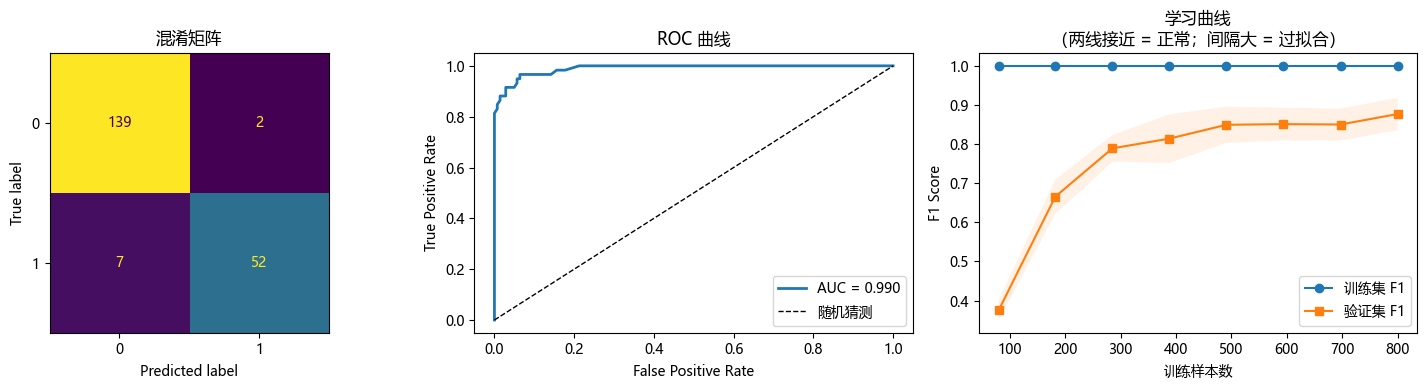

=== 5 折交叉验证 ===
逻辑回归       F1: 0.732 ± 0.032
随机森林       F1: 0.860 ± 0.045

详细报告:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       141
           1       0.96      0.88      0.92        59

    accuracy                           0.95       200
   macro avg       0.96      0.93      0.94       200
weighted avg       0.96      0.95      0.95       200



In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10,
                            random_state=42, weights=[0.7, 0.3])  # 轻度不平衡
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 混淆矩阵
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title('混淆矩阵')

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='随机猜测')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 曲线')
axes[1].legend()

# 学习曲线：诊断偏差/方差
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1', n_jobs=-1
)
train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
axes[2].plot(train_sizes, train_mean, 'o-', label='训练集 F1')
axes[2].plot(train_sizes, val_mean,   's-', label='验证集 F1')
axes[2].fill_between(train_sizes,
                      train_mean - train_scores.std(axis=1),
                      train_mean + train_scores.std(axis=1), alpha=0.1)
axes[2].fill_between(train_sizes,
                      val_mean - val_scores.std(axis=1),
                      val_mean + val_scores.std(axis=1), alpha=0.1)
axes[2].set_xlabel('训练样本数')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('学习曲线\n（两线接近 = 正常；间隔大 = 过拟合）')
axes[2].legend()

plt.tight_layout()
plt.show()

# 交叉验证
print('=== 5 折交叉验证 ===')
for name, clf in [('逻辑回归', LogisticRegression(max_iter=1000)),
                  ('随机森林', RandomForestClassifier(n_estimators=50, random_state=42))]:
    scores = cross_val_score(clf, X, y, cv=5, scoring='f1')
    print(f'{name:<10} F1: {scores.mean():.3f} ± {scores.std():.3f}')

print(f'\n详细报告:\n{classification_report(y_test, y_pred)}')